In [1]:
!pip install torch torchvision transformers pillow matplotlib pandas numpy sentencepiece

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.0 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 16.1 MB/s  0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 7.6/123.0 MB 47.1 MB/s eta 0:00:03
   --- ------------------------------------ 12.1/123.0 MB 29.1 MB/s eta 0:00:04
   ----- ---------------------------------- 17.3/123.0 MB 27.3 MB/s eta 0:00:04
   ------- -------------------------------- 21.8/123.0 MB 29.9 MB/s eta 0:00:04
   ------- -------------------------------- 23.1/123.0 MB 21.8 MB/s eta 0:00:05
   ------- -------------------------------- 24.4/123.0 MB 18.8 MB/s eta 0:00:06
   -------- ------------------------------- 26.0/123.0 MB 17.3 MB/s eta 0:00:06
   --------- ------------------------------ 27.8/123.0 MB 16.5 MB/s eta 0:00:06
   ---------- ----------------------------- 33.8/123.0 MB 17.5 MB/s eta


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Cargar una imagen de prueba

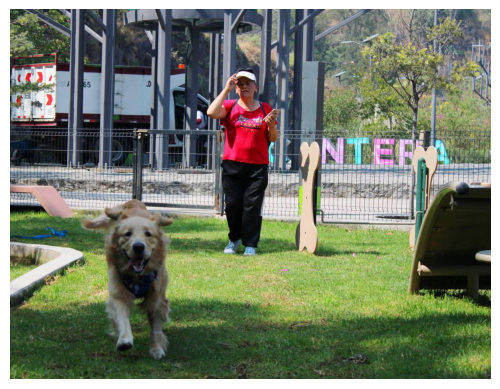

In [3]:
image_path = "imagenes_practica/perro_parque.jpg"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

# Arquitectura CNN + RNN para Image Captioning

In [4]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

In [7]:
model_name = "nlpconnect/vit-gpt2-image-captioning"

caption_model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
caption_processor = ViTImageProcessor.from_pretrained(model_name)

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jpach\.cache\huggingface\hub\models--nlpconnect--vit-gpt2-image-captioning. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not install

In [8]:
caption_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [9]:
def generar_caption_transformer_basico(image):
    '''Genera un caption para una imagen utilizando un modelo transformer básico.'''
    pixel_values = caption_processor(images = image, return_tensors="pt").pixel_values.to(device)
    
    output_ids = caption_model.generate(
        pixel_values,
        max_length = 20,
        num_beams = 4
    )
    
    caption = caption_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

In [10]:
caption_cnn_rnn = generar_caption_transformer_basico(image)
print("Caption generado por el modelo transformer básico:", caption_cnn_rnn)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Caption generado por el modelo transformer básico: a woman standing next to a dog on a lawn 


In [11]:
imagenes = [
    "imagenes_practica/perro_parque.jpg",
    "imagenes_practica/aula_estudiantes.jpg",
    "imagenes_practica/ciudad_noche.jpg",
    "imagenes_practica/comida_restaurante.jpg",
    "imagenes_practica/persona_computadora.jpg",
]

resultados = []

for path in imagenes:
    img = Image.open(path).convert("RGB")
    caption = generar_caption_transformer_basico(img)
    resultados.append({"imagen": path, "caption": caption})
    
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("captions_transformer.csv", index=False)
print(df_resultados)

                                      imagen  \
0         imagenes_practica/perro_parque.jpg   
1     imagenes_practica/aula_estudiantes.jpg   
2         imagenes_practica/ciudad_noche.jpg   
3   imagenes_practica/comida_restaurante.jpg   
4  imagenes_practica/persona_computadora.jpg   

                                             caption  
0          a woman standing next to a dog on a lawn   
1        a large group of people sitting at a table   
2  a city street filled with lots of traffic at n...  
3                 a table with plates of food on it   
4  a man sitting on a couch using a laptop computer   


# Arquitectura de transformers para Image Captioning

In [12]:
from transformers import BlipProcessor, BlipForConditionalGeneration

In [13]:
blip_name = "Salesforce/blip-image-captioning-base"

In [14]:
blip_processor = BlipProcessor.from_pretrained(blip_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_name).to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jpach\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you ei

In [15]:
def generar_caption_blip(image):
    '''Genera un caption para una imagen usando un modelo BLIP.'''
    inputs = blip_processor(image, return_tensors="pt").to(device)
    
    output_ids = blip_model.generate(
        **inputs,
        max_new_tokens = 30
    )
    
    caption = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    
    return caption

In [16]:
caption_transformer = generar_caption_blip(image)
print("\nCaption generado por el modelo BLIP:", caption_transformer)


Caption generado por el modelo BLIP: a woman walking a dog in a park


In [17]:
resultados_blip = []

for path in imagenes:
    img = Image.open(path).convert("RGB")
    caption = generar_caption_blip(img)
    resultados_blip.append({"imagen": path, "caption": caption})
    
df_resultados_blip = pd.DataFrame(resultados_blip)
df_resultados_blip.to_csv("captions_blip.csv", index=False)
df_resultados_blip

,imagen,caption
0,imagenes_practica/perro_parque.jpg,a woman walking a dog in a park
1,imagenes_practica/aula_estudiantes.jpg,students in a classroom
2,imagenes_practica/ciudad_noche.jpg,bangkok cityscapeat night
3,imagenes_practica/comida_restaurante.jpg,people eating at a restaurant
4,imagenes_practica/persona_computadora.jpg,man sitting on a couch using a laptop


# Arquitectura CLIP para Image Captioning

In [18]:
from transformers import CLIPProcessor, CLIPModel

In [19]:
clip_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_name)

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jpach\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fall

In [20]:
def seleccionar_caption_con_clip(image, captions):
    '''Selecciona el caption más relevante para una imagen utilizando CLIP.'''
    
    inputs = clip_processor(
        text = captions,
        images = image,
        return_tensors = "pt",
        padding = True
    ).to(device)
    
    outputs = clip_model(**inputs)
    
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)
    
    mejor_indice = probs.argmax().item()
    
    return captions[mejor_indice], probs.detach().cpu().numpy()[0]

In [24]:
caption_candidatos = [
    "A group of students in a classroom",
    "A dog running in a park",
    "A person driving a motorcycle",
    "A plate of food on a restaurant table",
    "A city skyline at night",
    "A car driving on a highway",
    "A person working on a computer"
]

mejor_caption, probabilidades = seleccionar_caption_con_clip(image, caption_candidatos)
print("\nCaption seleccionado por CLIP:", mejor_caption)


Caption seleccionado por CLIP: A dog running in a park


In [25]:
for caption, prob in zip(caption_candidatos, probabilidades):
    print(f"Caption: '{caption}' - Probabilidad de relevancia: {prob:.4f}")

Caption: 'A group of students in a classroom' - Probabilidad de relevancia: 0.0001
Caption: 'A dog running in a park' - Probabilidad de relevancia: 0.9998
Caption: 'A person driving a motorcycle' - Probabilidad de relevancia: 0.0000
Caption: 'A plate of food on a restaurant table' - Probabilidad de relevancia: 0.0000
Caption: 'A city skyline at night' - Probabilidad de relevancia: 0.0000
Caption: 'A car driving on a highway' - Probabilidad de relevancia: 0.0000
Caption: 'A person working on a computer' - Probabilidad de relevancia: 0.0001


In [26]:
resultados_clip = []

for path in imagenes:
    img = Image.open(path).convert("RGB")
    
    mejor_caption, probabilidades = seleccionar_caption_con_clip(img, caption_candidatos)
    resultados_clip.append({
        "imagen": path,
        "mejor_caption": mejor_caption,
        "probabilidad_maxima": float(np.max(probabilidades))
    })
    
df_resultados_clip = pd.DataFrame(resultados_clip)
df_resultados_clip.to_csv("captions_clip.csv", index=False)
df_resultados_clip

,imagen,mejor_caption,probabilidad_maxima
0,imagenes_practica/perro_parque.jpg,A dog running in a park,0.999836
1,imagenes_practica/aula_estudiantes.jpg,A group of students in a classroom,0.999942
2,imagenes_practica/ciudad_noche.jpg,A city skyline at night,0.999990
3,imagenes_practica/comida_restaurante.jpg,A plate of food on a restaurant table,0.999975
4,imagenes_practica/persona_computadora.jpg,A person working on a computer,0.998579


# Comparación de resultados

In [27]:
df_comparacion = pd.concat([df_resultados, df_resultados_blip, df_resultados_clip], ignore_index=True)
df_comparacion.to_csv("comparacion_captions.csv", index=False)
df_comparacion

,imagen,caption,mejor_caption,probabilidad_maxima
0,imagenes_practica/perro_parque.jpg,a woman standing next to a dog on a lawn,NaN,NaN
1,imagenes_practica/aula_estudiantes.jpg,a large group of people sitting at a table,NaN,NaN
2,imagenes_practica/ciudad_noche.jpg,a city street filled with lots of traffic at n...,NaN,NaN
3,imagenes_practica/comida_restaurante.jpg,a table with plates of food on it,NaN,NaN
4,imagenes_practica/persona_computadora.jpg,a man sitting on a couch using a laptop computer,NaN,NaN
5,imagenes_practica/perro_parque.jpg,a woman walking a dog in a park,NaN,NaN
6,imagenes_practica/aula_estudiantes.jpg,students in a classroom,NaN,NaN
7,imagenes_practica/ciudad_noche.jpg,bangkok cityscapeat night,NaN,NaN
8,imagenes_practica/comida_restaurante.jpg,people eating at a restaurant,NaN,NaN
9,imagenes_practica/persona_computadora.jpg,man sitting on a couch using a laptop,NaN,NaN
